In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler

import warnings
warnings.filterwarnings("ignore")
%matplotlib inline
sns.set_theme(context='notebook', palette='muted', style='darkgrid')
pd.set_option('display.max_columns', None)

In [31]:

df = pd.read_csv('data/alzheimers_disease_data.csv')

print(f"Kích thước dữ liệu: {df.shape}")
display(df.head().T)

df.info()

print(f"Số lượng giá trị thiếu:\n{df.isnull().sum()}")
print(f"\nSố dòng trùng lặp: {df.duplicated().sum()}")

Kích thước dữ liệu: (2149, 35)


,0,1,2,3,4
PatientID,4751,4752,4753,4754,4755
Age,73,89,73,74,89
Gender,0,0,0,1,0
Ethnicity,0,0,3,0,0
EducationLevel,2,0,1,1,0
BMI,22.927749,26.827681,17.795882,33.800817,20.716974
Smoking,0,0,0,1,0
AlcoholConsumption,13.297218,4.542524,19.555085,12.209266,18.454356
PhysicalActivity,6.327112,7.619885,7.844988,8.428001,6.310461
DietQuality,1.347214,0.518767,1.826335,7.435604,0.795498


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2149 entries, 0 to 2148
Data columns (total 35 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PatientID                  2149 non-null   int64  
 1   Age                        2149 non-null   int64  
 2   Gender                     2149 non-null   int64  
 3   Ethnicity                  2149 non-null   int64  
 4   EducationLevel             2149 non-null   int64  
 5   BMI                        2149 non-null   float64
 6   Smoking                    2149 non-null   int64  
 7   AlcoholConsumption         2149 non-null   float64
 8   PhysicalActivity           2149 non-null   float64
 9   DietQuality                2149 non-null   float64
 10  SleepQuality               2149 non-null   float64
 11  FamilyHistoryAlzheimers    2149 non-null   int64  
 12  CardiovascularDisease      2149 non-null   int64  
 13  Diabetes                   2149 non-null   int64

In [32]:
# Loại bỏ các thuộc tính không có giá trị thống kê cho mô hình dự đoán.
# Xóa các cột định danh
df.drop(['PatientID', 'DoctorInCharge'], axis=1, inplace=True)

In [33]:
# Xác định các cột số (numerical) dựa trên số lượng giá trị duy nhất > 10
numerical_columns = [col for col in df.columns if df[col].nunique() > 10]

# Xác định các cột phân loại (categorical)
categorical_columns = df.columns.difference(numerical_columns).difference(['Diagnosis']).to_list()

print(f"Cột dạng số: {numerical_columns}")
print(f"Cột phân loại: {categorical_columns}")

Cột dạng số: ['Age', 'BMI', 'AlcoholConsumption', 'PhysicalActivity', 'DietQuality', 'SleepQuality', 'SystolicBP', 'DiastolicBP', 'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL', 'CholesterolTriglycerides', 'MMSE', 'FunctionalAssessment', 'ADL']
Cột phân loại: ['BehavioralProblems', 'CardiovascularDisease', 'Confusion', 'Depression', 'Diabetes', 'DifficultyCompletingTasks', 'Disorientation', 'EducationLevel', 'Ethnicity', 'FamilyHistoryAlzheimers', 'Forgetfulness', 'Gender', 'HeadInjury', 'Hypertension', 'MemoryComplaints', 'PersonalityChanges', 'Smoking']


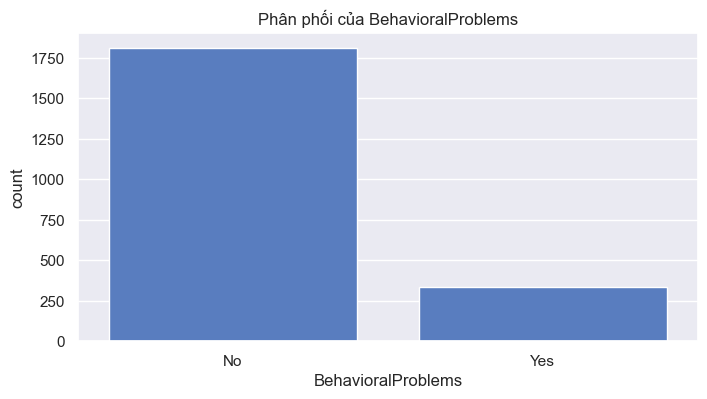

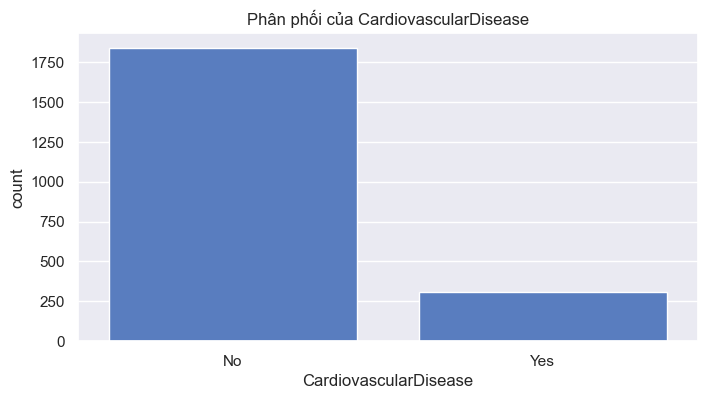

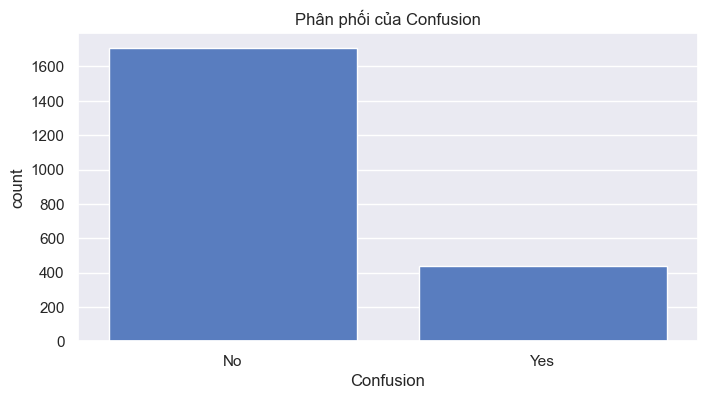

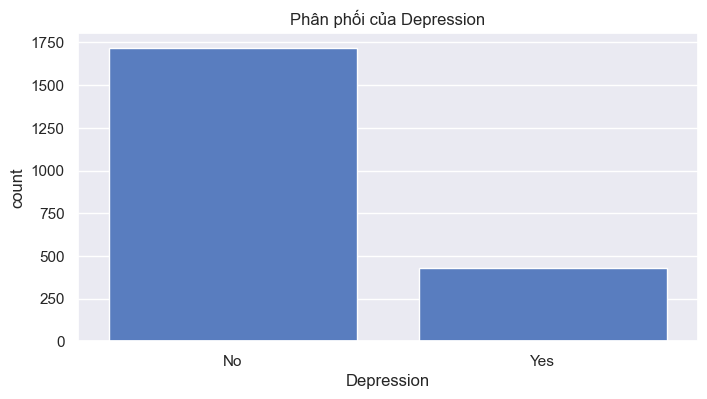

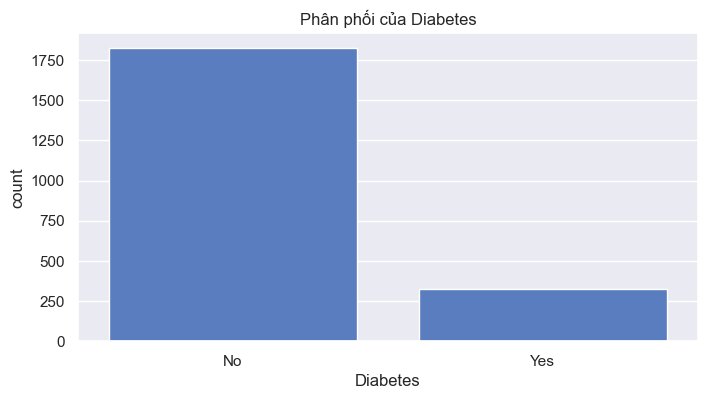

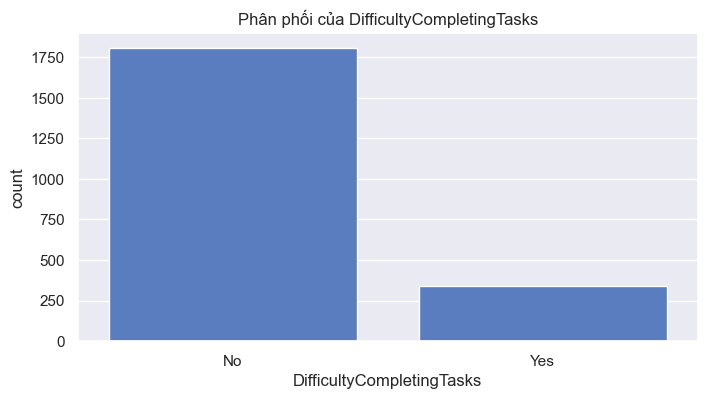

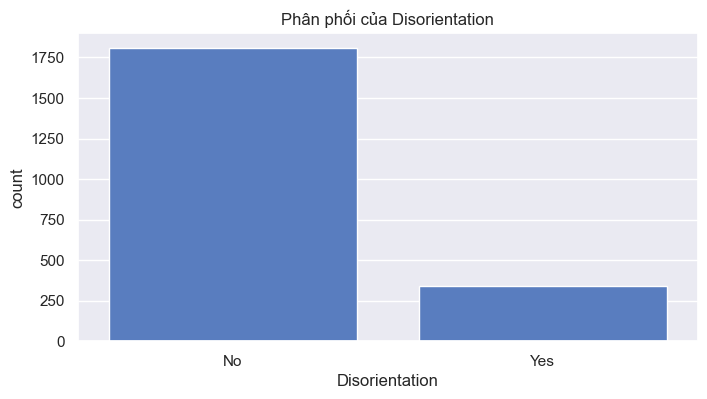

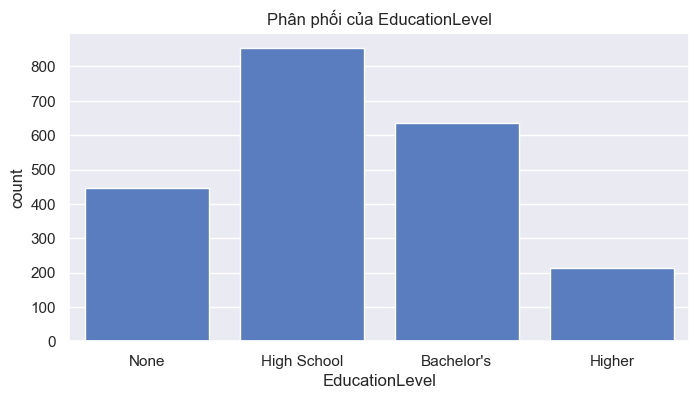

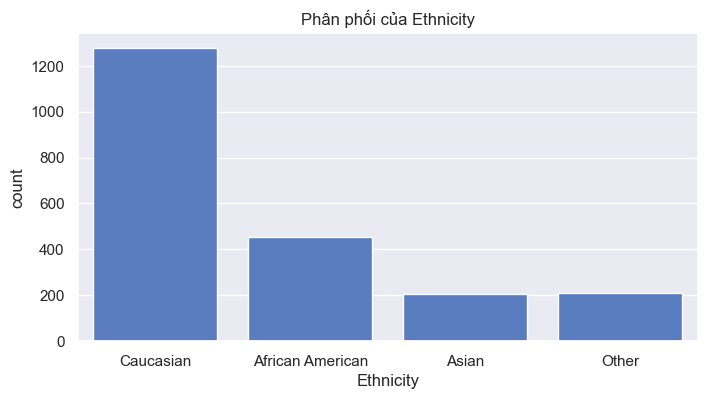

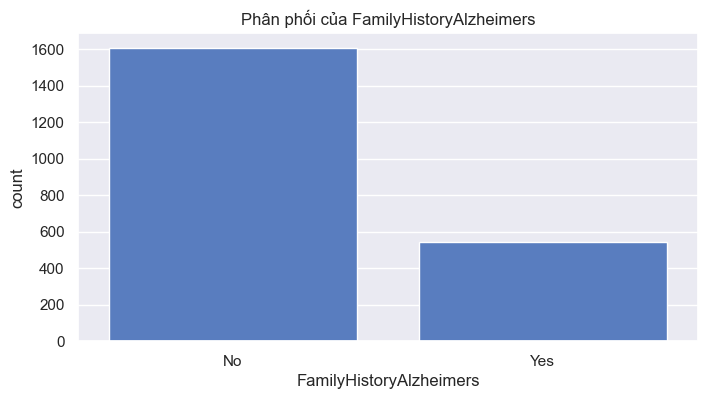

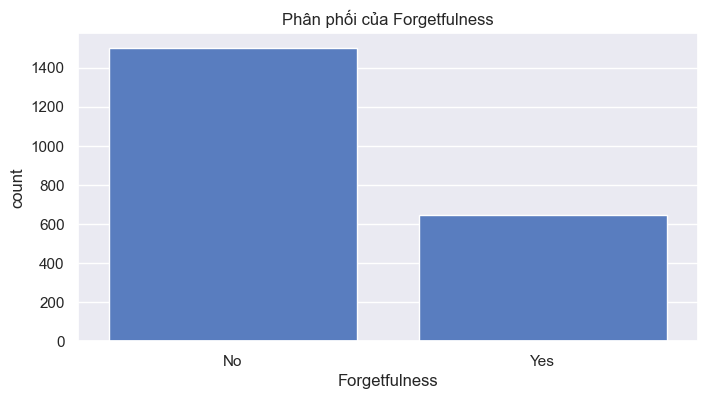

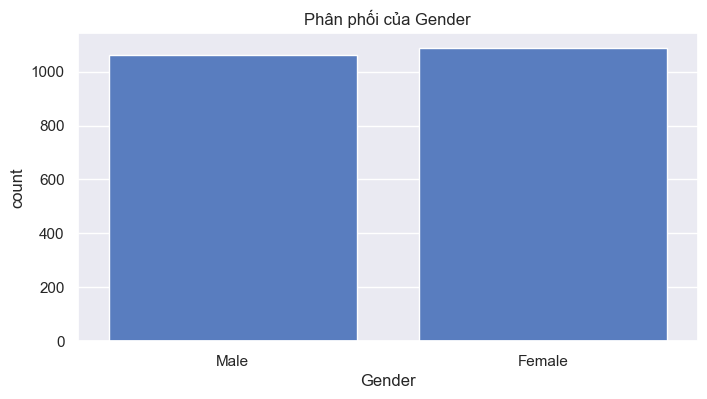

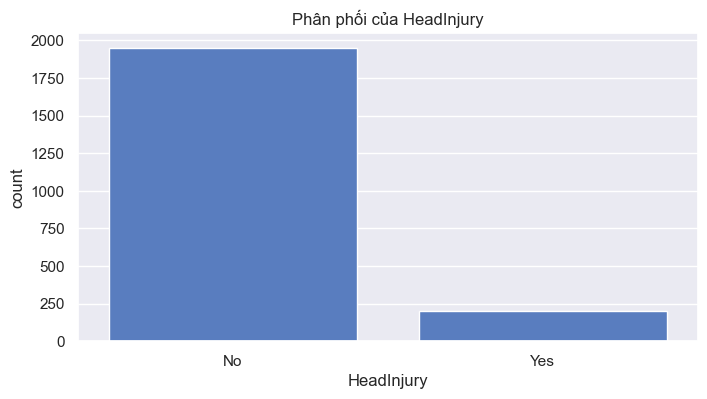

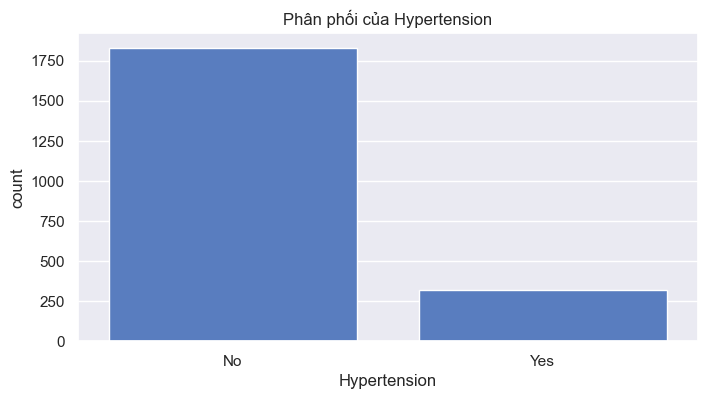

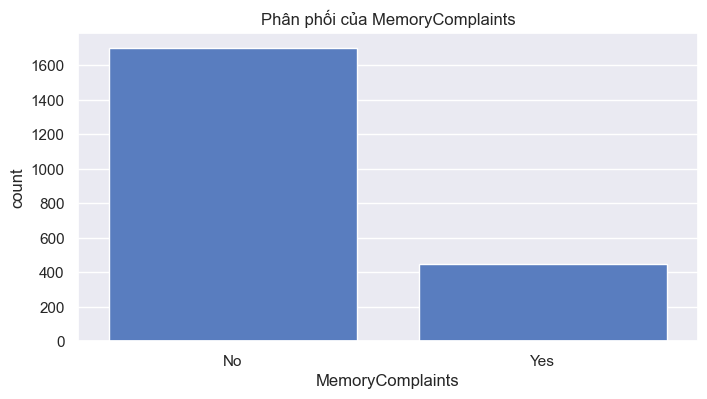

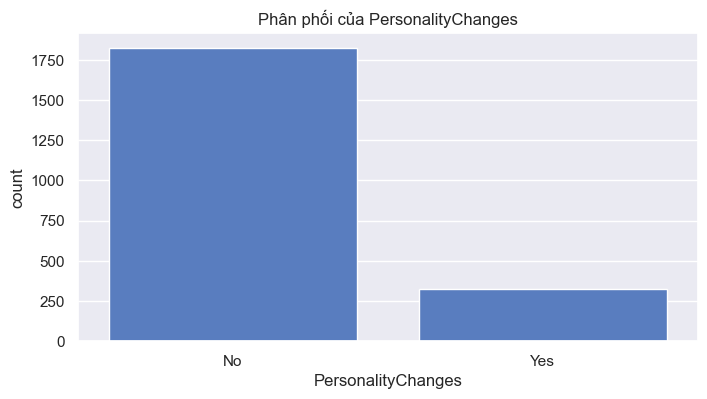

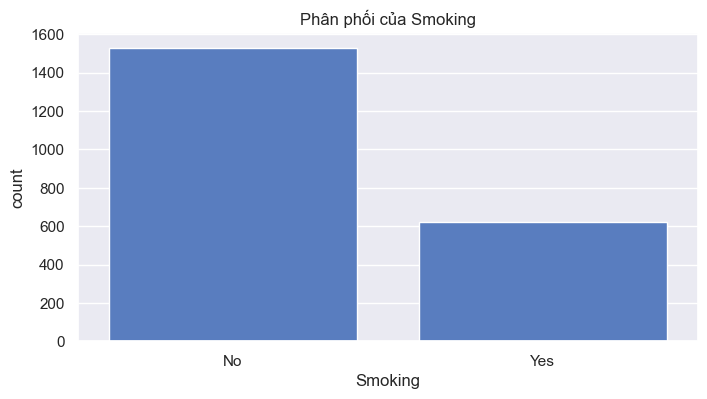

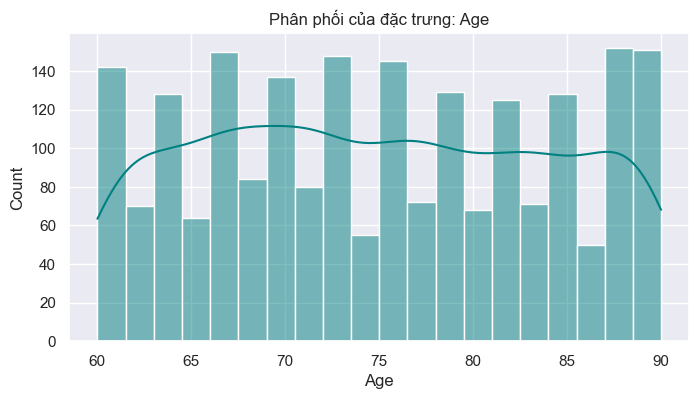

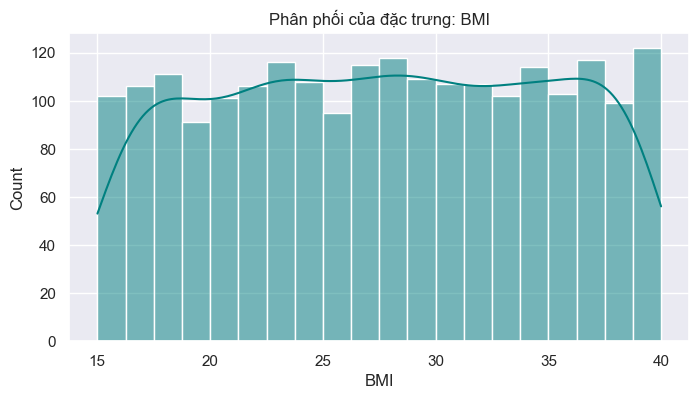

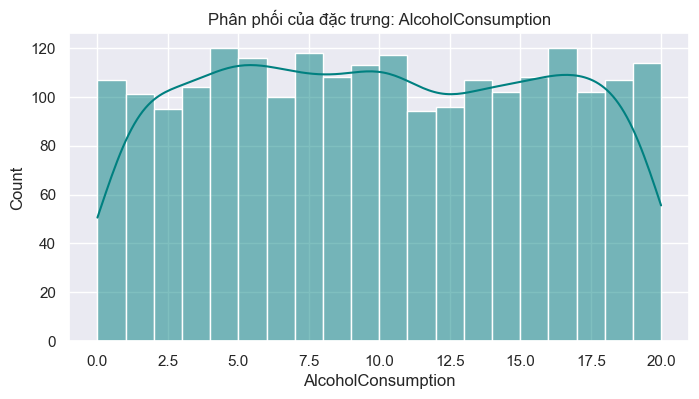

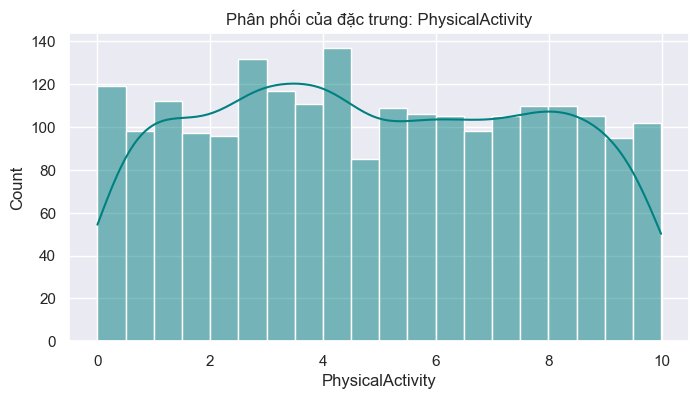

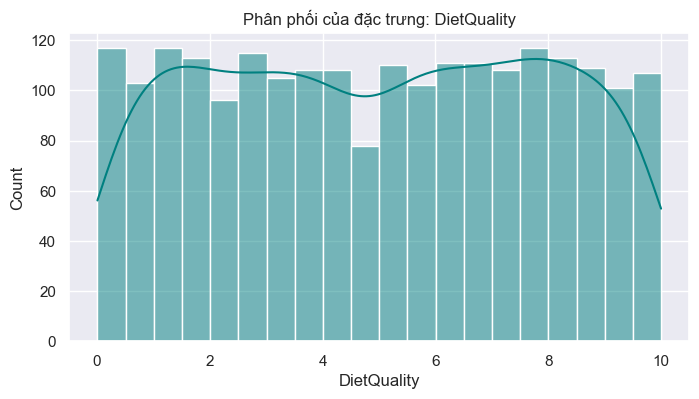

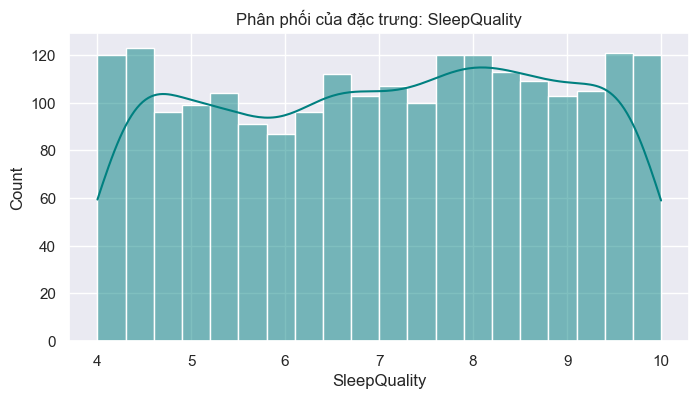

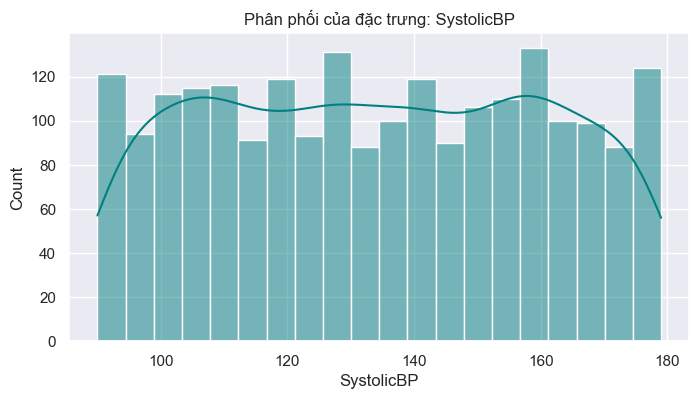

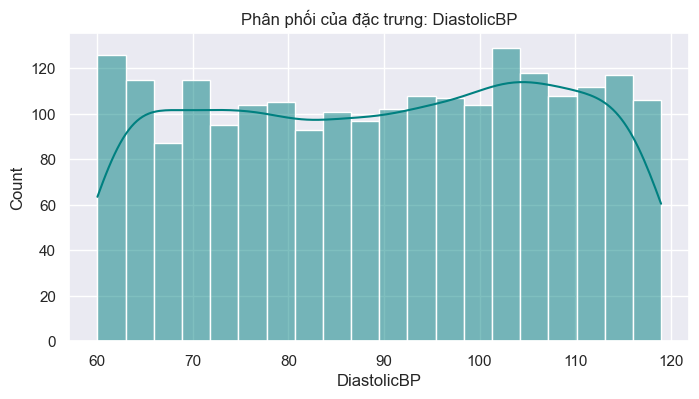

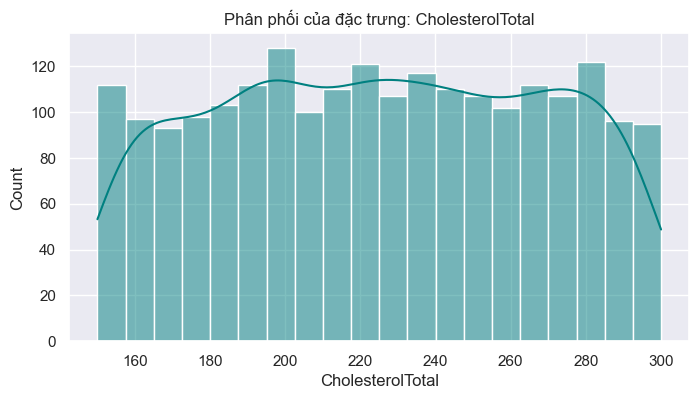

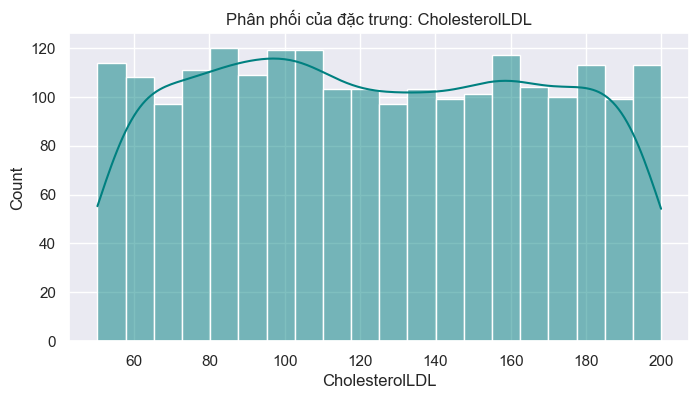

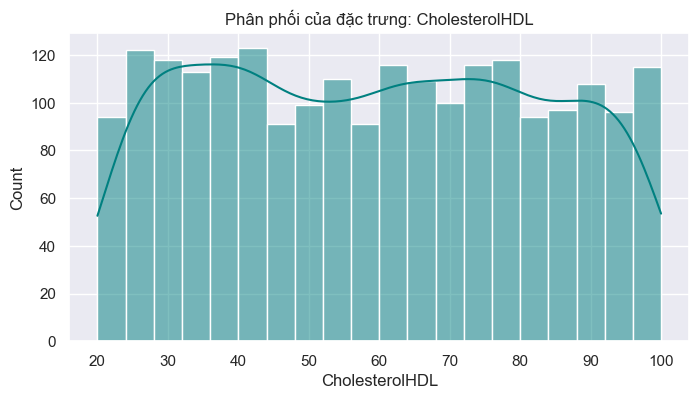

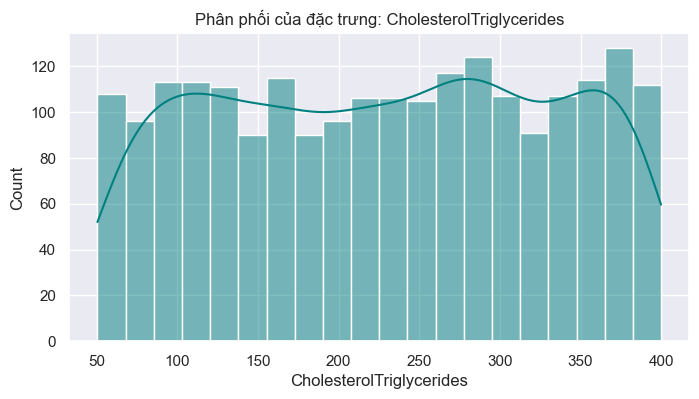

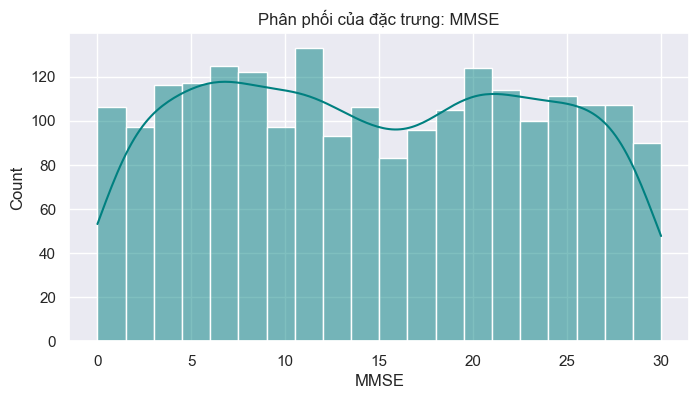

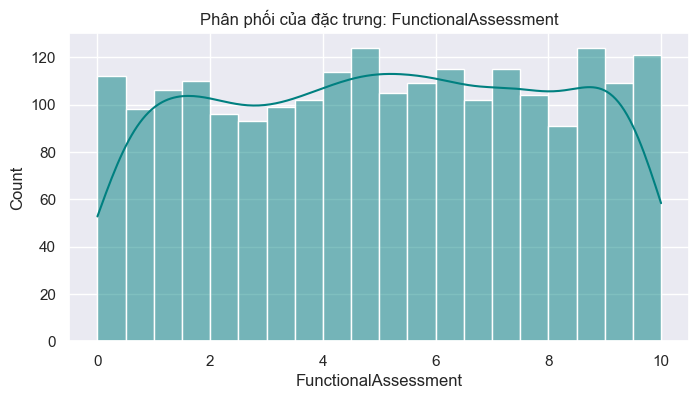

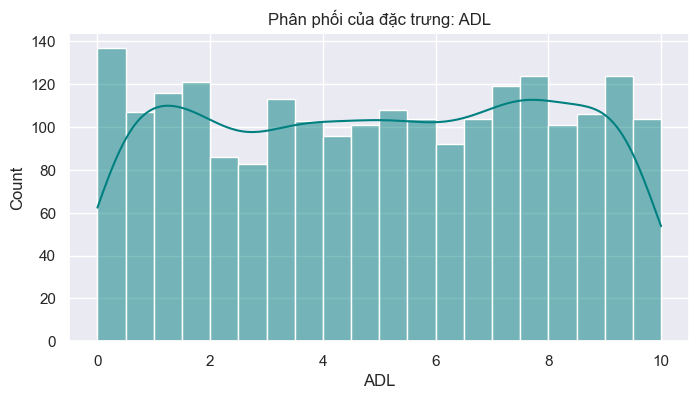

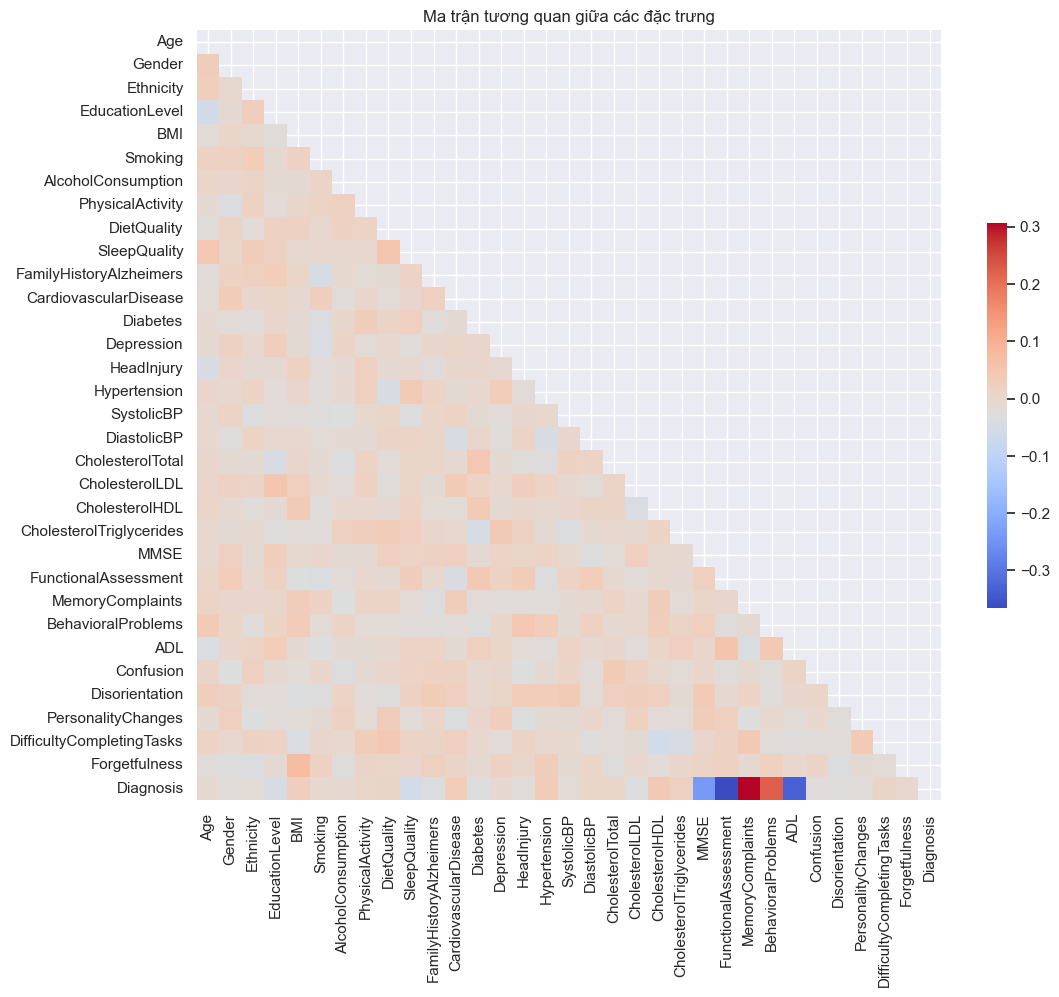

In [34]:
custom_labels = {
    'Gender': ['Male', 'Female'],
    'Ethnicity': ['Caucasian', 'African American', 'Asian', 'Other'],
    'EducationLevel': ['None', 'High School', 'Bachelor\'s', 'Higher'],
    'Smoking': ['No', 'Yes'], 'FamilyHistoryAlzheimers': ['No', 'Yes'],
    'CardiovascularDisease': ['No', 'Yes'], 'Diabetes': ['No', 'Yes'],
    'Depression': ['No', 'Yes'], 'HeadInjury': ['No', 'Yes'],
    'Hypertension': ['No', 'Yes'], 'MemoryComplaints': ['No', 'Yes'],
    'BehavioralProblems': ['No', 'Yes'], 'Confusion': ['No', 'Yes'],
    'Disorientation': ['No', 'Yes'], 'PersonalityChanges': ['No', 'Yes'],
    'DifficultyCompletingTasks': ['No', 'Yes'], 'Forgetfulness': ['No', 'Yes']
}

for column in categorical_columns:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x=column)
    plt.title(f'Phân phối của {column}')
    
    if column in custom_labels:
        plt.xticks(ticks=range(len(custom_labels[column])), labels=custom_labels[column])
    plt.show()

# ## 4.3. Trực quan hóa biến dạng số và Tương quan

# Biểu đồ Histogram cho các cột số
for column in numerical_columns:
    plt.figure(figsize=(8, 4))
    sns.histplot(data=df, x=column, kde=True, bins=20, color='teal')
    plt.title(f'Phân phối của đặc trưng: {column}')
    plt.show()


# Ma trận tương quan (Correlation Matrix)
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(df.corr(), dtype=bool))
sns.heatmap(df.corr(), cmap="coolwarm", annot=False, mask=mask, cbar_kws={"shrink": .5})
plt.title("Ma trận tương quan giữa các đặc trưng")
plt.show()


--- Tương quan Pearson giữa các đặc trưng và nhãn Diagnosis ---
Diagnosis                    1.000000
MemoryComplaints             0.306742
BehavioralProblems           0.224350
CholesterolHDL               0.042584
Hypertension                 0.035080
CardiovascularDisease        0.031490
BMI                          0.026343
CholesterolTriglycerides     0.022672
DifficultyCompletingTasks    0.009069
DietQuality                  0.008506
CholesterolTotal             0.006394
PhysicalActivity             0.005945
DiastolicBP                  0.005293
Forgetfulness               -0.000354
Smoking                     -0.004865
Age                         -0.005488
Depression                  -0.005893
AlcoholConsumption          -0.007618
Ethnicity                   -0.014782
SystolicBP                  -0.015615
Confusion                   -0.019186
PersonalityChanges          -0.020627
Gender                      -0.020975
HeadInjury                  -0.021411
Disorientation         

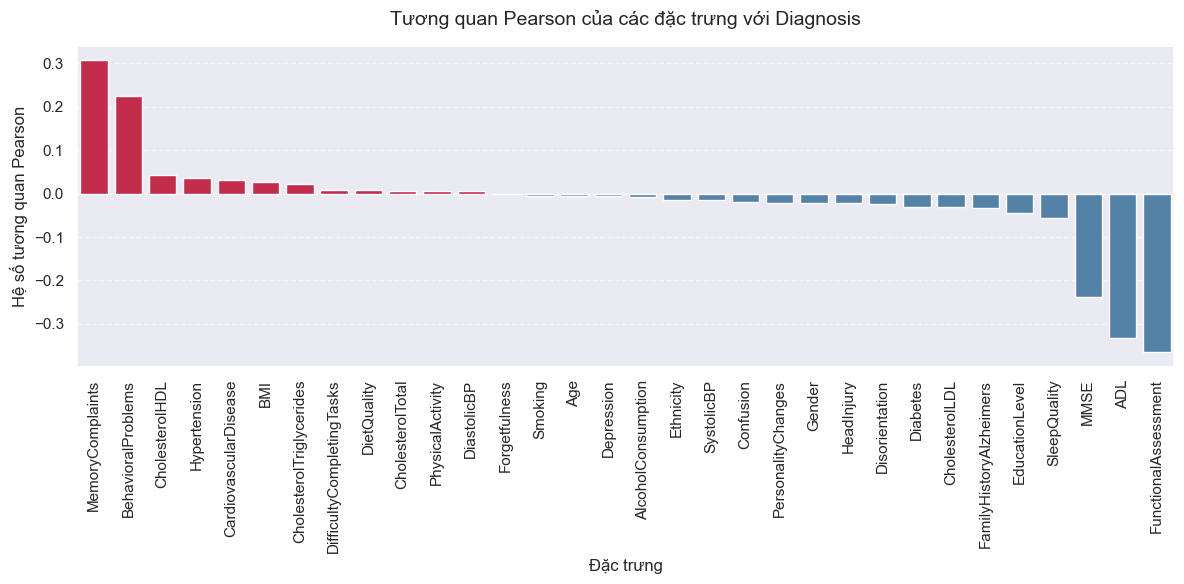

In [35]:
corr_with_diagnosis = df.corr()['Diagnosis'].sort_values(ascending=False)

print("\n--- Tương quan Pearson giữa các đặc trưng và nhãn Diagnosis ---")
print(corr_with_diagnosis)
plt.figure(figsize=(12, 6))
corr_features = corr_with_diagnosis.drop('Diagnosis')

colors = ['crimson' if c > 0 else 'steelblue' for c in corr_features.values]
sns.barplot(x=corr_features.index, y=corr_features.values, palette=colors)

plt.title('Tương quan Pearson của các đặc trưng với Diagnosis', fontsize=14, pad=15)
plt.ylabel('Hệ số tương quan Pearson', fontsize=12)
plt.xlabel('Đặc trưng', fontsize=12)
plt.xticks(rotation=90) 
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [36]:
# 1. Mã hóa One-Hot cho cột 'Ethnicity' (Biến định danh không có thứ tự)
ethnicity_encoded = pd.get_dummies(df['Ethnicity'], prefix='Ethnicity')
df = pd.concat([df.drop(columns=['Ethnicity']), ethnicity_encoded], axis=1)


# 2. Chuẩn hóa các biến dạng số
columns_to_scale = ['Age', 'BMI', 'AlcoholConsumption', 'PhysicalActivity', 'DietQuality', 
                    'SleepQuality', 'SystolicBP', 'DiastolicBP', 'CholesterolTotal', 
                    'CholesterolLDL', 'CholesterolHDL', 'CholesterolTriglycerides', 
                    'MMSE', 'FunctionalAssessment', 'ADL']

# Kết hợp Min-Max Scaler (đưa về 0-1)
min_max_scaler = MinMaxScaler()
df[columns_to_scale] = min_max_scaler.fit_transform(df[columns_to_scale])

# Kết hợp Standard Scaler (đưa về Z-score)
standard_scaler = StandardScaler()
df[columns_to_scale] = standard_scaler.fit_transform(df[columns_to_scale])

Dữ liệu sau khi chuẩn hóa (5 dòng đầu):


,Age,Gender,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,FamilyHistoryAlzheimers,CardiovascularDisease,Diabetes,Depression,HeadInjury,Hypertension,SystolicBP,DiastolicBP,CholesterolTotal,CholesterolLDL,CholesterolHDL,CholesterolTriglycerides,MMSE,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,Ethnicity_0,Ethnicity_1,Ethnicity_2,Ethnicity_3
0,-0.212368,0,2,-0.655225,0,0.565923,0.492525,-1.253593,1.119918,0,0,1,1,0,0,0.298159,-1.014750,0.403677,-1.572661,-1.114429,-0.648199,0.779037,0.497506,0,0,-1.104434,0,0,0,1,0,0,True,False,False,False
1,1.567757,0,0,-0.114751,0,-0.954895,0.945093,-1.538442,0.056836,0,0,0,0,0,0,-0.742572,-1.469595,0.140248,1.593119,0.845730,0.650721,0.680297,0.704907,0,0,-0.810601,0,0,0,0,1,0,True,False,False,False
2,-0.212368,0,1,-1.366428,0,1.653006,1.023896,-1.088855,1.487380,1,0,0,0,0,0,-1.359301,1.486898,1.386812,0.668569,0.445615,-1.418585,-0.859222,0.281813,0,0,0.724491,0,1,0,1,0,0,False,False,False,True
3,-0.101111,1,1,0.851625,1,0.376930,1.227995,0.839804,0.760833,0,0,0,0,0,0,-0.626935,1.430043,-1.542715,-1.360103,0.388780,0.483468,-0.088723,1.343346,0,1,0.508044,0,0,0,0,0,0,True,False,False,False
4,1.567757,0,0,-0.961607,0,1.461793,0.486696,-1.443293,-0.824566,0,0,0,0,0,0,-1.552029,1.543754,0.291653,-0.725756,-0.111924,0.617060,-0.143712,0.333665,0,0,-1.684679,0,0,1,1,0,0,True,False,False,False


Age                          0
Gender                       0
EducationLevel               0
BMI                          0
Smoking                      0
AlcoholConsumption           0
PhysicalActivity             0
DietQuality                  0
SleepQuality                 0
FamilyHistoryAlzheimers      0
CardiovascularDisease        0
Diabetes                     0
Depression                   0
HeadInjury                   0
Hypertension                 0
SystolicBP                   0
DiastolicBP                  0
CholesterolTotal             0
CholesterolLDL               0
CholesterolHDL               0
CholesterolTriglycerides     0
MMSE                         0
FunctionalAssessment         0
MemoryComplaints             0
BehavioralProblems           0
ADL                          0
Confusion                    0
Disorientation               0
PersonalityChanges           0
DifficultyCompletingTasks    0
Forgetfulness                0
Diagnosis                    0
Ethnicit

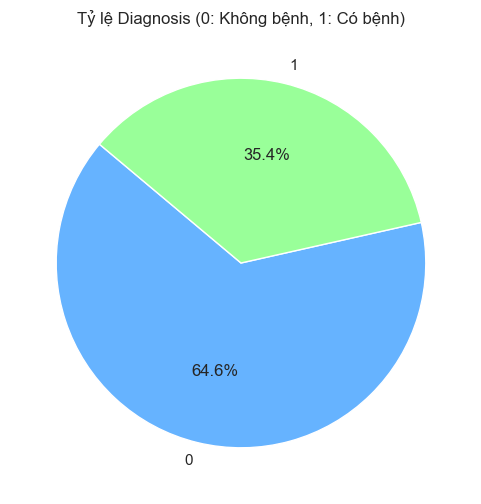

In [37]:
print("Dữ liệu sau khi chuẩn hóa (5 dòng đầu):")
display(df.head())

print(df.isnull().sum())
print(df.duplicated().sum())

# Kiểm tra phân phối nhãn Diagnosis
plt.figure(figsize=(6, 6))
df['Diagnosis'].value_counts().plot.pie(autopct='%1.1f%%', startangle=140, colors=['#66b3ff','#99ff99'])
plt.title('Tỷ lệ Diagnosis (0: Không bệnh, 1: Có bệnh)')
plt.ylabel('')
plt.show()

In [38]:
df.to_csv('data/alzheimers_preprocessed.csv', index=False)
print("Đã lưu tệp alzheimers_preprocessed.csv thành công!")

Đã lưu tệp alzheimers_preprocessed.csv thành công!


In [39]:
from sklearn.model_selection import train_test_split

X = df.drop('Diagnosis', axis=1)
y = df['Diagnosis']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Kích thước tập huấn luyện: {X_train.shape}")
print(f"Kích thước tập kiểm thử: {X_test.shape}")

Kích thước tập huấn luyện: (1719, 35)
Kích thước tập kiểm thử: (430, 35)
